# 100,000 movie ratings, in plain SQL

The MovieLens "small" dataset: **100,836 ratings from 610 users on 9,742 movies** (1996-2018), with genres and tags. Eight questions in SQL only: rating distribution with a window share, a **weighted rating** that stops one-vote movies from topping the chart (a window average supplies the prior), genre popularity from a many-to-many table, user activity deciles with `NTILE`, release decades, and the most *divisive* films from a standard deviation built out of sums. Python only runs the queries and draws the charts.

**Data:** [MovieLens latest small](https://grouplens.org/datasets/movielens/latest/) from GroupLens Research (University of Minnesota). It may be used for research and personal projects but not redistributed, so this repo has only the script that downloads it: run `python build_db.py` once (about 1 MB) and point `MOVIELENS_DB` at the SQLite file it creates.

**Reading the data.** Ratings are 0.5 to 5 stars in half-star steps. Every user has rated at least 20 movies. The release year is read from the title, and a few titles have none. This is a small, old sample, so the results describe these 610 users, not film audiences in general.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("MOVIELENS_DB", "movielens.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,movie_genres,22050
1,movies,9742
2,ratings,100836
3,tags,3683


## 1. How do people rate movies?

A plain `GROUP BY` with `SUM(COUNT(*)) OVER ()` for the share of each star value. People are generous: there are more 4-star than 3-star ratings.

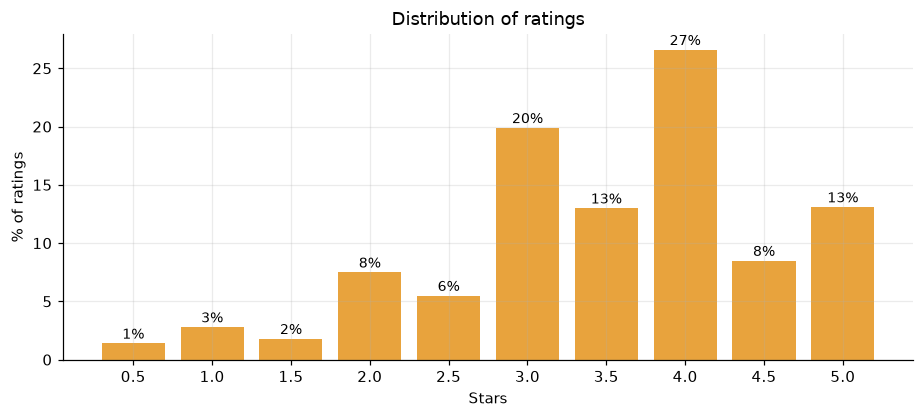

,rating,ratings,share_pct
0,0.5,1370,1.4
1,1.0,2811,2.8
2,1.5,1791,1.8
3,2.0,7551,7.5
4,2.5,5550,5.5
5,3.0,20047,19.9
6,3.5,13136,13.0
7,4.0,26818,26.6
8,4.5,8551,8.5
9,5.0,13211,13.1


In [3]:
distribution = q("""
SELECT rating,
       COUNT(*)                                            AS ratings,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS share_pct
FROM ratings
GROUP BY rating
ORDER BY rating
""")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
ax.bar(distribution.rating.astype(str), distribution.share_pct, color=AMBER)
for x, v in enumerate(distribution.share_pct):
    ax.text(x, v + 0.4, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_xlabel("Stars")
ax.set_ylabel("% of ratings")
ax.set_title("Distribution of ratings")
fig.tight_layout()
plt.show()
distribution

## 2. What are the best movies, once one-vote wonders are handled?

A movie rated 5.0 by a single person is not the best movie ever. The **weighted rating** pulls each average towards the overall average (`AVG(rating) OVER ()`) in proportion to how few ratings it has: `v/(v+m)*R + m/(v+m)*C` with m = 50. The `raw_rank` column shows where the plain average would have put each film among all 9,700.

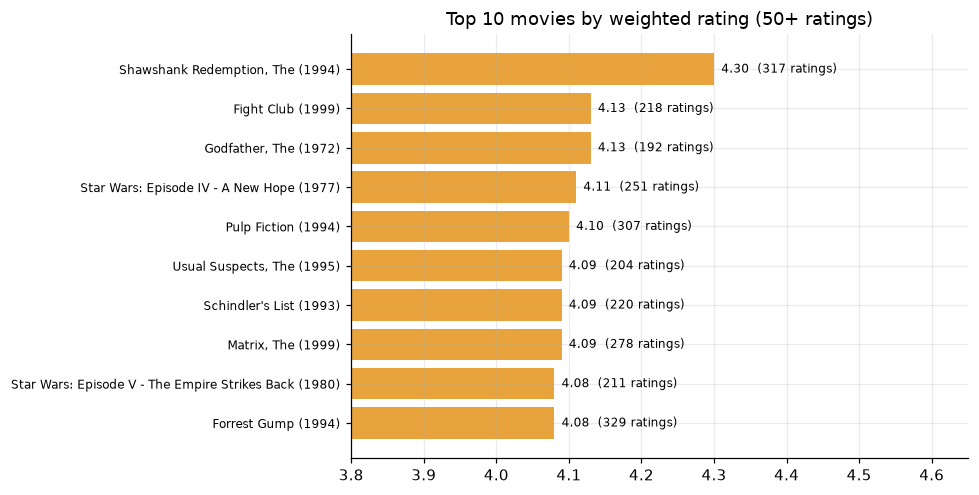

,title,votes,avg_rating,weighted_rating,raw_rank
0,"Shawshank Redemption, The (1994)",317,4.43,4.30,723
1,Fight Club (1999),218,4.27,4.13,809
2,"Godfather, The (1972)",192,4.29,4.13,801
3,Star Wars: Episode IV - A New Hope (1977),251,4.23,4.11,936
4,Pulp Fiction (1994),307,4.20,4.10,972
5,"Usual Suspects, The (1995)",204,4.24,4.09,934
6,Schindler's List (1993),220,4.22,4.09,941
7,"Matrix, The (1999)",278,4.19,4.09,973
8,Star Wars: Episode V - The Empire Strikes Back...,211,4.22,4.08,950
9,Forrest Gump (1994),329,4.16,4.08,1036


In [4]:
best = q("""
WITH stats AS (
    SELECT movie_id, COUNT(*) AS votes, AVG(rating) AS avg_rating
    FROM ratings
    GROUP BY movie_id
),
scored AS (
    SELECT movie_id, votes, avg_rating,
           RANK() OVER (ORDER BY avg_rating DESC) AS raw_rank,
           1.0 * votes / (votes + 50) * avg_rating
             + 50.0 / (votes + 50) * (SELECT AVG(rating) FROM ratings) AS weighted_rating
    FROM stats
)
SELECT m.title,
       s.votes,
       ROUND(s.avg_rating, 2)       AS avg_rating,
       ROUND(s.weighted_rating, 2)  AS weighted_rating,
       s.raw_rank
FROM scored s
JOIN movies m USING (movie_id)
WHERE s.votes >= 50
ORDER BY s.weighted_rating DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(best.title[::-1], best.weighted_rating[::-1], color=AMBER)
for y, (w, v) in enumerate(zip(best.weighted_rating[::-1], best.votes[::-1])):
    ax.text(w + 0.01, y, f"{w:.2f}  ({v} ratings)", va="center", fontsize=8)
ax.set_xlim(3.8, best.weighted_rating.max() + 0.35)
ax.set_title("Top 10 movies by weighted rating (50+ ratings)")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()
best

## 3. Which genres are watched most, and rated best?

Genres live in their own table (one row per movie and genre), so joining it to the ratings counts a rating once for every genre the movie has.

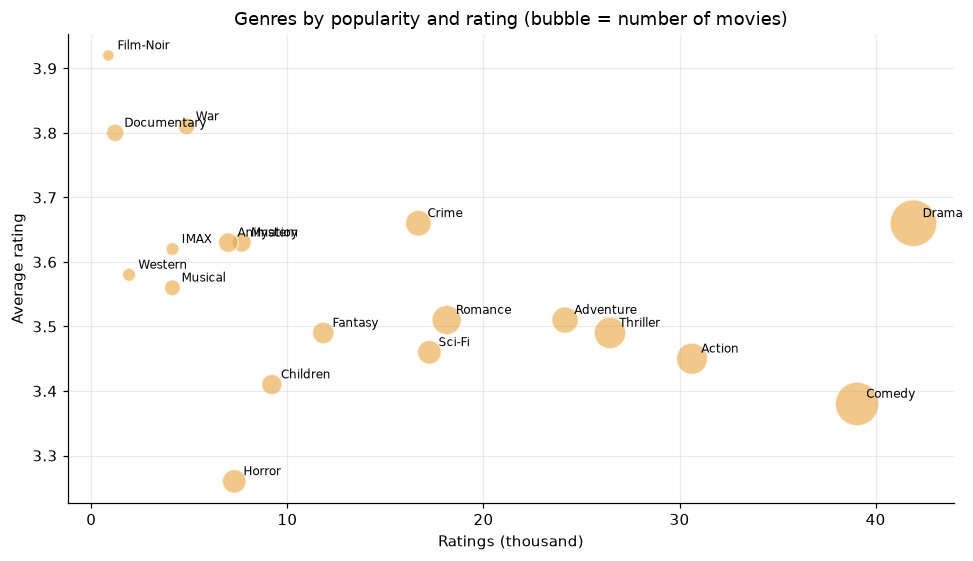

,genre,movies,ratings,share_of_genre_ratings_pct,avg_rating
11,Horror,977,7291,2.7,3.26
18,Film-Noir,85,870,0.3,3.92


In [5]:
genres = q("""
SELECT g.genre,
       COUNT(DISTINCT g.movie_id)                          AS movies,
       COUNT(*)                                            AS ratings,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS share_of_genre_ratings_pct,
       ROUND(AVG(r.rating), 2)                             AS avg_rating
FROM movie_genres g
JOIN ratings r USING (movie_id)
GROUP BY g.genre
ORDER BY ratings DESC
""")

fig, ax = plt.subplots(figsize=(9, 5.2))
sizes = genres.movies / genres.movies.max() * 900 + 40
ax.scatter(genres.ratings / 1000, genres.avg_rating, s=sizes, color=AMBER, alpha=0.6, edgecolor="white")
for _, r in genres.iterrows():
    ax.annotate(r.genre, (r.ratings / 1000, r.avg_rating), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Ratings (thousand)")
ax.set_ylabel("Average rating")
ax.set_title("Genres by popularity and rating (bubble = number of movies)")
fig.tight_layout()
plt.show()
genres.sort_values("avg_rating").iloc[[0, -1]]

## 4. Has rating behaviour changed over the years?

Ratings per calendar year and the average rating, with `LAG()` for the change in the average from the previous year.

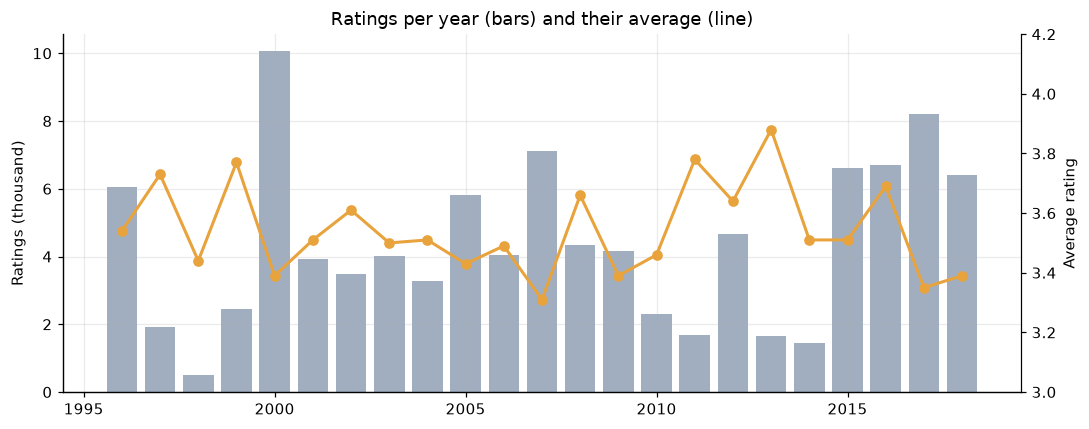

,year,ratings,active_users,avg_rating,change_vs_prev_year
4,2000,10061,56,3.39,-0.38
21,2017,8198,58,3.35,-0.34
11,2007,7114,46,3.31,-0.18
20,2016,6703,47,3.69,0.18


In [6]:
yearly = q("""
WITH yearly AS (
    SELECT CAST(substr(rated_at, 1, 4) AS INT)  AS year,
           COUNT(*)                             AS ratings,
           COUNT(DISTINCT user_id)              AS active_users,
           ROUND(AVG(rating), 2)                AS avg_rating
    FROM ratings
    GROUP BY year
)
SELECT year, ratings, active_users, avg_rating,
       ROUND(avg_rating - LAG(avg_rating) OVER (ORDER BY year), 2) AS change_vs_prev_year
FROM yearly
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.year, yearly.ratings / 1000, color=GREY)
ax.set_ylabel("Ratings (thousand)")
ax2 = ax.twinx()
ax2.plot(yearly.year, yearly.avg_rating, color=AMBER, marker="o", lw=2)
ax2.set_ylim(3, 4.2)
ax2.set_ylabel("Average rating")
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Ratings per year (bars) and their average (line)")
fig.tight_layout()
plt.show()
yearly.sort_values("ratings", ascending=False).head(4)

## 5. How concentrated is the activity?

`NTILE(10)` cuts the users into ten equal groups by how many movies they rated, and a running `SUM() OVER` gives the cumulative share of all ratings from the heaviest raters downwards.

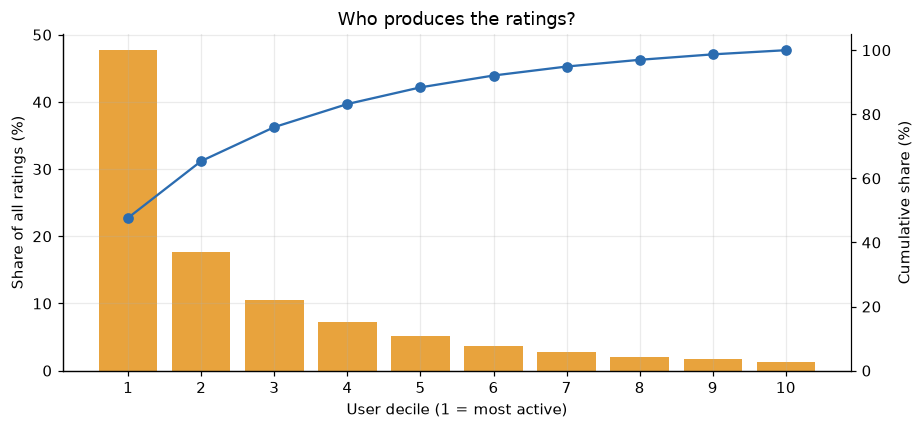

,decile,users,ratings,share_pct,cumulative_pct,avg_rating
0,1,61,48117,47.7,47.7,3.36
1,2,61,17879,17.7,65.4,3.65
2,3,61,10590,10.5,76.0,3.69
3,4,61,7326,7.3,83.2,3.60
4,5,61,5217,5.2,88.4,3.74
5,6,61,3708,3.7,92.1,3.70
6,7,61,2834,2.8,94.9,3.76
7,8,61,2157,2.1,97.0,3.82
8,9,61,1686,1.7,98.7,3.69
9,10,61,1322,1.3,100.0,3.57


In [7]:
users = q("""
WITH per_user AS (
    SELECT user_id, COUNT(*) AS ratings, AVG(rating) AS avg_rating
    FROM ratings
    GROUP BY user_id
),
bucketed AS (
    SELECT *, NTILE(10) OVER (ORDER BY ratings DESC) AS decile
    FROM per_user
)
SELECT decile,
       COUNT(*)                                                             AS users,
       SUM(ratings)                                                         AS ratings,
       ROUND(100.0 * SUM(ratings) / SUM(SUM(ratings)) OVER (), 1)           AS share_pct,
       ROUND(100.0 * SUM(SUM(ratings)) OVER (ORDER BY decile)
                   / SUM(SUM(ratings)) OVER (), 1)                          AS cumulative_pct,
       ROUND(AVG(avg_rating), 2)                                            AS avg_rating
FROM bucketed
GROUP BY decile
ORDER BY decile
""")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(users.decile.astype(str), users.share_pct, color=AMBER)
ax.set_xlabel("User decile (1 = most active)")
ax.set_ylabel("Share of all ratings (%)")
ax2 = ax.twinx()
ax2.plot(users.decile.astype(str), users.cumulative_pct, color=BLUE, marker="o")
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative share (%)")
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Who produces the ratings?")
fig.tight_layout()
plt.show()
users

## 6. Are older movies rated higher?

Rounding the release year down to the decade with integer arithmetic groups the movies; the join to the ratings then compares the number of movies, the number of ratings and the average rating per decade.

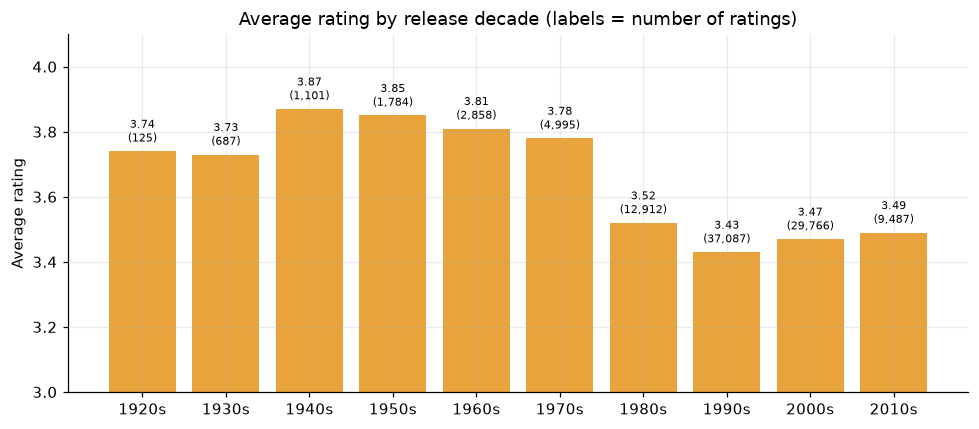

,decade,movies,ratings,avg_rating
0,1920,37,125,3.74
1,1930,134,687,3.73
2,1940,194,1101,3.87
3,1950,277,1784,3.85
4,1960,399,2858,3.81
5,1970,498,4995,3.78
6,1980,1175,12912,3.52
7,1990,2209,37087,3.43
8,2000,2848,29766,3.47
9,2010,1930,9487,3.49


In [8]:
decades = q("""
SELECT (m.release_year / 10) * 10          AS decade,
       COUNT(DISTINCT m.movie_id)          AS movies,
       COUNT(*)                            AS ratings,
       ROUND(AVG(r.rating), 2)             AS avg_rating
FROM movies m
JOIN ratings r USING (movie_id)
WHERE m.release_year >= 1920
GROUP BY decade
ORDER BY decade
""")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(decades.decade.astype(str) + "s", decades.avg_rating, color=AMBER)
for x, (v, n) in enumerate(zip(decades.avg_rating, decades.ratings)):
    ax.text(x, v + 0.03, f"{v:.2f}\n({n:,})", ha="center", fontsize=7)
ax.set_ylim(3, 4.1)
ax.set_ylabel("Average rating")
ax.set_title("Average rating by release decade (labels = number of ratings)")
fig.tight_layout()
plt.show()
decades

## 7. Which movies split the audience?

SQLite has no standard deviation, but it can be computed from sums: variance = `AVG(r*r) - AVG(r)^2`, and `sqrt()` of it is the spread. A high spread means people either love or hate the movie. Only movies with 100 or more ratings are considered.

In [9]:
divisive = q("""
SELECT m.title,
       COUNT(*)                                                      AS ratings,
       ROUND(AVG(r.rating), 2)                                       AS avg_rating,
       ROUND(sqrt(AVG(r.rating * r.rating) - AVG(r.rating) * AVG(r.rating)), 2) AS spread,
       ROUND(100.0 * AVG(r.rating <= 2), 0)                          AS rated_2_or_less_pct,
       ROUND(100.0 * AVG(r.rating >= 4.5), 0)                        AS rated_4_5_or_more_pct
FROM ratings r
JOIN movies m USING (movie_id)
GROUP BY r.movie_id
HAVING ratings >= 100
ORDER BY spread DESC
LIMIT 10
""")

divisive

,title,ratings,avg_rating,spread,rated_2_or_less_pct,rated_4_5_or_more_pct
0,Austin Powers: The Spy Who Shagged Me (1999),121,3.20,1.21,19.0,16.0
1,"Big Lebowski, The (1998)",106,3.92,1.13,8.0,43.0
2,Dumb & Dumber (Dumb and Dumber) (1994),133,3.06,1.12,23.0,14.0
3,Star Wars: Episode I - The Phantom Menace (1999),140,3.11,1.12,26.0,11.0
4,Four Weddings and a Funeral (1994),103,3.52,1.11,13.0,17.0
5,2001: A Space Odyssey (1968),109,3.89,1.10,13.0,38.0
6,Ace Ventura: Pet Detective (1994),161,3.04,1.07,27.0,11.0
7,E.T. the Extra-Terrestrial (1982),122,3.77,1.07,11.0,32.0
8,Titanic (1997),140,3.41,1.05,16.0,15.0
9,Babe (1995),128,3.65,1.04,12.0,23.0


## What the queries say

- **People are generous.** The average rating is 3.50 and the most common single rating is 4.0 (26.6% of ratings), then 3.0 (19.9%) and 5.0 (13.1%). Only 13.5% of ratings are 2 stars or lower.
- **A plain average is a poor way to rank movies.** 3,446 of the 9,742 movies were rated by one user only, and 296 movies average exactly 5.0, so they crowd the top of any raw ranking. With the weighted rating (and at least 50 ratings), *The Shawshank Redemption* leads (4.30 from 317 ratings), then *Fight Club* and *The Godfather* (4.13 each). By plain average Shawshank would rank only 723rd.
- **Drama and comedy are the most rated genres, but not equally liked.** Drama has 41,928 ratings and averages 3.66, comedy has 39,053 ratings and averages 3.38. Horror has the lowest average (3.26), film-noir the highest (3.92, from only 870 ratings), then war (3.81).
- **The yearly averages are noisy, not a trend.** Average rating swings between 3.31 and 3.88 from one year to the next, but some years have as few as 11 active users (1998), so a handful of people move the number. The busiest year was 2000 with 10,061 ratings.
- **A tenth of the users produce nearly half of the ratings.** The 61 most active users account for 47.7% of all ratings (48,117) and the top 20% for 65.4%. The heaviest raters are also the toughest: their average rating is 3.36, against 3.6-3.8 for the other deciles.
- **Older movies are rated higher.** Movies from the 1940s average 3.87 and from the 1950s 3.85, against 3.43 for the 1990s. A likely reason is selection (people tend to watch old films that are already considered classics), but the data cannot confirm it.
- **Some famous movies split the audience.** *Austin Powers: The Spy Who Shagged Me* has the widest spread of ratings (1.21, with 19% giving 2 stars or less and 16% giving 4.5 or more). *The Big Lebowski* is loved by 43% (4.5 stars or more) and rated 2 or less by 8%, and *Star Wars: Episode I* is rated 2 or less by 26%.

**Limits:** this is the small MovieLens sample (610 users, ratings up to 2018), so the results describe these users and not film audiences in general; years with few users are noisy; a few movies have no release year in the title.

**Techniques covered:** window shares, a weighted (Bayesian) rating with a window average as the prior, `RANK`, many-to-many joins, `NTILE`, `LAG`, integer arithmetic for decades and a standard deviation built from sums with `sqrt`.
